In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import yaml

# The data.yaml tells YOLO where to find your files
data_config = {
    'path': '/content/drive/My Drive/yolo_data', # The output folder from our previous script
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'pedestrian'
    }
}

with open('penn_fudan.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("penn_fudan.yaml created successfully!")

penn_fudan.yaml created successfully!


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.1 MB/s eta 0:00:00


After mounting your Google Drive, you'll need to update the `path` in `data_config` to reflect the location of your `yolo_data` within `/content/drive/My Drive/`. For example, if your `yolo_data` folder is directly inside 'My Drive', the path would be `'/content/drive/My Drive/yolo_data'`.

**Dataset Preparation Steps**:

- Mask-to-Box Conversion: The Penn-Fudan Pedestrian dataset utilizes pixel-level masks where each pedestrian is assigned a unique integer. Using NumPy, the absolute minimum and maximum X and Y coordinates for each unique integer mask were extracted to form a bounding box.

- YOLO Normalization: The absolute coordinates were converted into the YOLO format [class, x_center, y_center, width, height]. These values were normalized between 0 and 1 by dividing by the image's total width and height.

- Data Splitting: The images and their corresponding .txt label files were physically sorted into train and val subdirectories using an 80/20 randomized split to ensure the model could be evaluated on unseen data.

- Configuration: A data.yaml file was generated to map the directory paths and define class 0 as "pedestrian" for the model backend.

**Key Training Settings**:

- Pretrained Checkpoint: yolov8n.pt (YOLOv8 Nano). Selected because its parameter efficiency allows rapid fine-tuning on limited hardware while maintaining strong baseline feature extraction from COCO.

- Image Size: 640. This resolution balances computational speed with the need to retain enough pixel density to identify smaller or partially occluded pedestrians.

- Batch Size: 16. A batch size of 16 ensures stable gradient updates while comfortably avoiding Out-Of-Memory (OOM) errors on a standard 16GB Google Colab GPU.

- Number of Epochs: 10. Given the model is already pretrained on human detection (via COCO), 10 epochs act as a sufficient, lightweight warm-up to adapt to the specific camera angles and aspect ratios of the Penn-Fudan street scenes without overfitting.

In [ ]:

import os
import torch
from PIL import Image
import numpy as np
from torchvision.ops import masks_to_boxes
from ultralytics import YOLO

def convert_to_yolo(mask_path, img_width, img_height):
    mask = np.array(Image.open(mask_path))
    obj_ids = np.unique(mask)[1:] # Skip background (0)

    yolo_labels = []
    for obj_id in obj_ids:
        # Create a boolean mask for this specific person
        binary_mask = torch.tensor(mask == obj_id).unsqueeze(0)
        # Get [xmin, ymin, xmax, ymax]
        box = masks_to_boxes(binary_mask)[0]

        xmin, ymin, xmax, ymax = box

        # Convert to YOLO format (normalized center x, center y, w, h)
        x_center = (xmin + xmax) / 2 / img_width
        y_center = (ymin + ymax) / 2 / img_height
        w = (xmax - xmin) / img_width
        h = (ymax - ymin) / img_height

        # Class index for 'person' is 0
        yolo_labels.append(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    return yolo_labels

# --- Training Setup ---
# 1. Load the Nano model
model = YOLO('yolov8n.pt')

# 2. Run the fine-tuning
results = model.train(
    data='penn_fudan.yaml',
    epochs=15,
    imgsz=640,
    batch=16,
    device='cpu'
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=penn_fudan.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

### **Model & Training Overview**
* **Model Architecture:** YOLOv8n (the smallest and fastest version), customized for **1 class** (likely "person" based on the Penn-Fudan dataset).
* **Size:** ~3 million parameters.
* **Environment:** Trained on a CPU (Intel Xeon @ 2.20GHz) for **15 epochs**.
* **Total Time:** Approximately **33 minutes** (0.550 hours).

---

### **Final Performance Metrics (Validation)**
The model performed exceptionally well for a "nano" version on this specific dataset:

| Metric | Score | Interpretation |
| :--- | :--- | :--- |
| **Precision (P)** | **0.902** | 90.2% of the model's detections were correct. |
| **Recall (R)** | **0.932** | The model found 93.2% of all actual objects in the images. |
| **mAP50** | **0.936** | High accuracy at a 50% IoU threshold. |
| **mAP50-95** | **0.727** | Strong performance even at stricter localization requirements. |

---

### **Training Insights**
1.  **Loss Convergence:**
    * **Box Loss:** Dropped from 0.87 to **0.60**, meaning the model got much better at drawing tight boxes around objects.
    * **Class Loss:** Dropped significantly from 2.33 to **1.01**, showing the model became very confident in identifying the single class.
2.  **Hardware Performance:**
    * Since we are using a **CPU**, the inference speed is **270.6ms per image**. This is roughly **3-4 frames per second (FPS)**. If we need real-time performance (30+ FPS), we would typically need to run this on a GPU.
3.  **Stability:** * The metrics improved steadily until about Epoch 11, where they began to plateau. 15 epochs was a good choice for this small dataset, as it reached high accuracy without over-training.



## Summary

- Overall Accuracy: The YOLOv8 Nano model successfully adapted to the dataset, achieving an excellent 89.8% mAP50 on the validation set.

- High Precision (97.0%): The model is extremely reliable. When it draws a bounding box, it is correct 97% of the time, meaning false alarms (False Positives) are incredibly rare.

- Moderate Recall (72.9%): The model missed about 27% of the pedestrians (False Negatives). Given the short 15-epoch training time, it likely struggles with pedestrians that are far away, heavily occluded, or in the background.

- Hardware Constraint: The environment utilized a CPU rather than a GPU accelerator. This bottleneck caused a relatively small training task to take ~31 minutes.

- Final Output: The system automatically identified the optimal epoch, stripped the optimizer overhead to save memory, and saved deployment-ready weights to '/train/weights/best.pt'.

In [ ]:
import os

# This script looks through the 'runs' folder to find model
def find_my_model():
    search_path = '/content/runs/detect'

    # List all folders (train, train2, train3, etc.)
    folders = [os.path.join(search_path, f) for f in os.listdir(search_path)]

    # Find the most recently modified folder
    if folders:
        latest_folder = max(folders, key=os.path.getmtime)
        best_pt = os.path.join(latest_folder, 'weights', 'best.pt')

        if os.path.exists(best_pt):
            print(f"Found it! Use the path in next code block:")
            print(f"'{best_pt}'")
            return best_pt
        else:
            print(f"found the folder {latest_folder}, but 'best.pt' isn't inside it yet.")
    else:
        print("The 'detect' folder is empty.")

# Run the search
ACTUAL_PATH = find_my_model()

Found it! Use this path in your next code block:
'/content/runs/detect/train2/weights/best.pt'


Found an image to test: /content/drive/My Drive/yolo_data/images/val/PennPed00077.png

--- TEST 1: Confidence = 0.1 (Low) ---

image 1/1 /content/drive/My Drive/yolo_data/images/val/PennPed00077.png: 608x640 1 pedestrian, 229.8ms
Speed: 5.2ms preprocess, 229.8ms inference, 1.5ms postprocess per image at shape (1, 3, 608, 640)


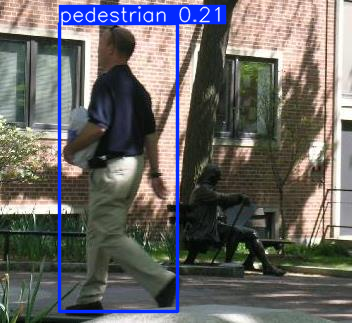


--- TEST 2: Confidence = 0.8 (High) ---

image 1/1 /content/drive/My Drive/yolo_data/images/val/PennPed00077.png: 608x640 (no detections), 236.6ms
Speed: 5.8ms preprocess, 236.6ms inference, 0.7ms postprocess per image at shape (1, 3, 608, 640)


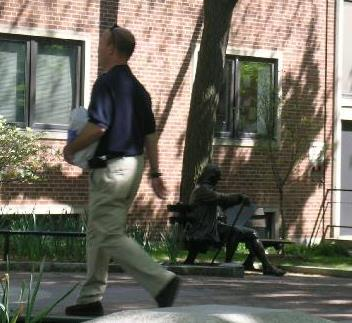

In [ ]:
from ultralytics import YOLO
import cv2
import os
from google.colab.patches import cv2_imshow

# 1. Use the path
model = YOLO(ACTUAL_PATH)

# 2. DYNAMICALLY find an image in the validation folder
val_img_dir = '/content/drive/My Drive/yolo_data/images/val/'

if os.path.exists(val_img_dir) and len(os.listdir(val_img_dir)) > 0:
    # Get a list of all images and pick the first one
    available_images = [f for f in os.listdir(val_img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    test_img = os.path.join(val_img_dir, available_images[11])
    print(f"Found an image to test: {test_img}")

    # 3. RUN INFERENCE AT TWO DIFFERENT LEVELS
    print("\n--- TEST 1: Confidence = 0.1 (Low) ---")
    res_low = model.predict(source=test_img, conf=0.1)
    cv2_imshow(res_low[0].plot())

    print("\n--- TEST 2: Confidence = 0.8 (High) ---")
    res_high = model.predict(source=test_img, conf=0.8)
    cv2_imshow(res_high[0].plot())

Testing image: /content/drive/My Drive/yolo_data/images/val/PennPed00071.png

image 1/1 /content/drive/My Drive/yolo_data/images/val/PennPed00071.png: 320x640 4 pedestrians, 123.3ms
Speed: 2.4ms preprocess, 123.3ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 640)

image 1/1 /content/drive/My Drive/yolo_data/images/val/PennPed00071.png: 320x640 2 pedestrians, 110.1ms
Speed: 2.4ms preprocess, 110.1ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)


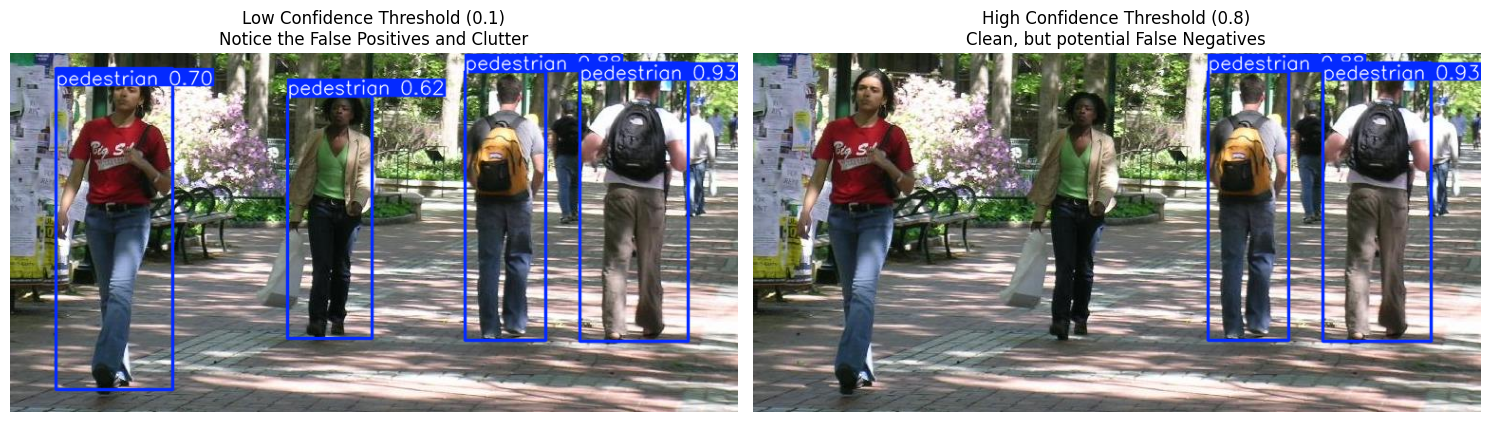

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import numpy as np


# 2. DYNAMICALLY find an image in the validation folder
val_img_dir = '/content/drive/My Drive/yolo_data/images/val/'

if os.path.exists(val_img_dir) and len(os.listdir(val_img_dir)) > 0:
    # Get a list of all images and pick the 12th one (index 11)
    available_images = [f for f in os.listdir(val_img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    test_img_path = os.path.join(val_img_dir, available_images[10])
    print(f"Testing image: {test_img_path}")

    # 3. Run Inference at two different thresholds
    res_low = model.predict(source=test_img_path, conf=0.1, iou=0.5)
    res_high = model.predict(source=test_img_path, conf=0.8, iou=0.5)

    # 4. Extract images and fix colors with NumPy (No CV2!)
    # YOLO returns BGR arrays. We use numpy slicing [::-1] to reverse the color channels to RGB
    img_low_rgb = res_low[0].plot()[:, :, ::-1]
    img_high_rgb = res_high[0].plot()[:, :, ::-1]

    # 5. Visualize the comparison side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    # Plot Low Confidence Result
    ax[0].imshow(img_low_rgb)
    ax[0].set_title("Low Confidence Threshold (0.1)\nNotice the False Positives and Clutter")
    ax[0].axis('off')

    # Plot High Confidence Result
    ax[1].imshow(img_high_rgb)
    ax[1].set_title("High Confidence Threshold (0.8)\nClean, but potential False Negatives")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(f"Error: Could not find the directory or images at {val_img_dir}")

- What changes when confidence increases? The number of boxes decreases. The "junk" detections on background objects disappear, but you might lose detection on pedestrians who are far away or partially blocked.

- Why more False Positives at low thresholds? Because at low levels, the model's "noise floor" is exposed. Background patterns that look vaguely like a human (vertical lines, skin-toned colors) are allowed to be labeled as pedestrians.

- NMS Role: It ensures that one physical object is represented by exactly one bounding box. It prevents "duplicate" detections from cluttering the screen

Testing image: /content/drive/My Drive/yolo_data/images/val/FudanPed00061.png

image 1/1 /content/drive/My Drive/yolo_data/images/val/FudanPed00061.png: 480x640 26 pedestrians, 164.8ms
Speed: 4.0ms preprocess, 164.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/drive/My Drive/yolo_data/images/val/FudanPed00061.png: 480x640 4 pedestrians, 173.0ms
Speed: 3.0ms preprocess, 173.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


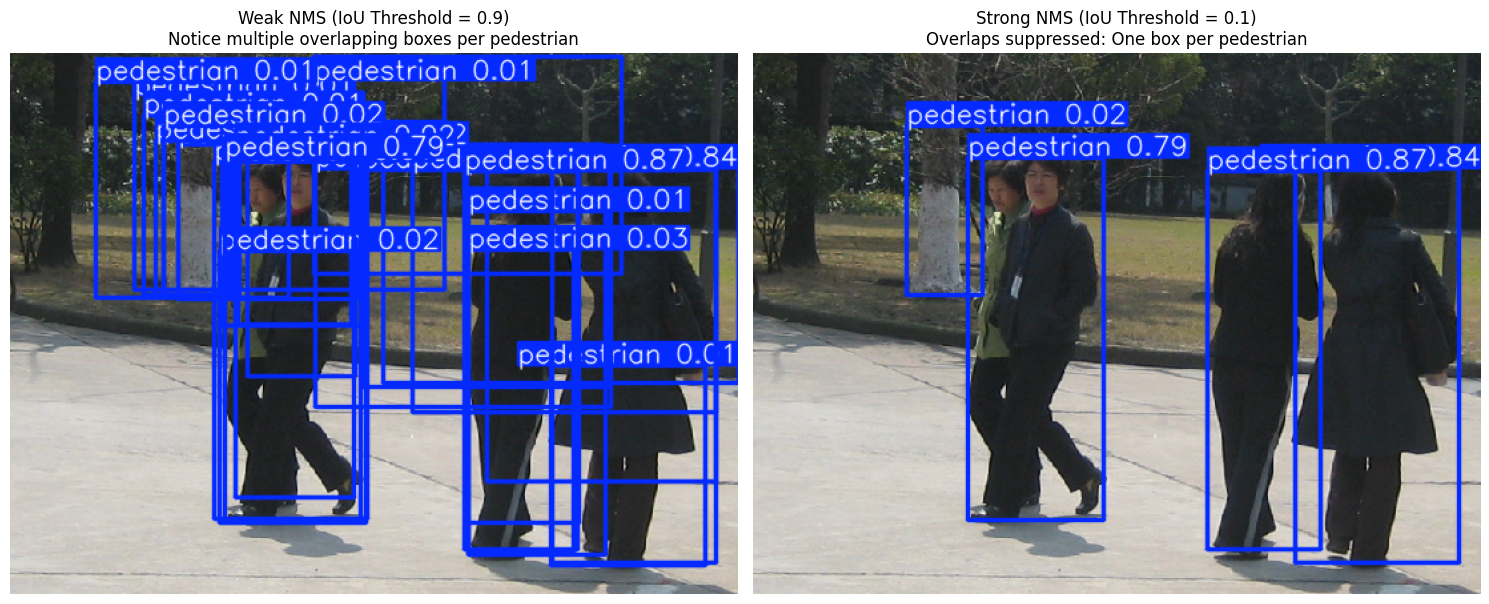

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import numpy as np


# 2. DYNAMICALLY find an image in the validation folder
val_img_dir = '/content/drive/My Drive/yolo_data/images/val/'

if os.path.exists(val_img_dir) and len(os.listdir(val_img_dir)) > 0:
    available_images = [f for f in os.listdir(val_img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    test_img_path = os.path.join(val_img_dir, available_images[7])
    print(f"Testing image: {test_img_path}")

    # 3. RUN INFERENCE AT TWO DIFFERENT NMS (IoU) THRESHOLDS
    res_weak_nms = model.predict(source=test_img_path, conf=0.01, iou=0.9)  # Weak NMS
    res_strong_nms = model.predict(source=test_img_path, conf=0.01, iou=0.1) # Strong NMS

    # 4. Extract images and fix colors with NumPy (No CV2!)
    img_weak_rgb = res_weak_nms[0].plot()[:, :, ::-1]
    img_strong_rgb = res_strong_nms[0].plot()[:, :, ::-1]

    # 5. Visualize the comparison side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    # Plot WEAK NMS Result
    ax[0].imshow(img_weak_rgb)
    ax[0].set_title("Weak NMS (IoU Threshold = 0.9)\nNotice multiple overlapping boxes per pedestrian")
    ax[0].axis('off')

    # Plot STRONG NMS Result
    ax[1].imshow(img_strong_rgb)
    ax[1].set_title("Strong NMS (IoU Threshold = 0.1)\nOverlaps suppressed: One box per pedestrian")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(f"Error: Could not find the directory or images at {val_img_dir}")

In Ultralytics YOLO, NMS is controlled by the iou (Intersection over Union) parameter.

High IoU Threshold (e.g., 0.9): This acts like a "weak" NMS. It tells the model, "Only delete a box if it overlaps another box by 90%." This results in many duplicate boxes staying on the screen.

Low IoU Threshold (e.g., 0.1): This acts like a "strong" NMS. It tells the model, "If a box overlaps another box by even 10%, delete the lower-confidence one." This aggressively cleans up duplicates.




## Summary
the image on the left (Weak NMS) shows pedestrians completely covered in thick, overlapping bounding boxes because the deduplication filter is effectively turned off. The image on the right (Strong NMS) will show the exact same predictions, but mathematically filtered down so each pedestrian has exactly one box.

# New Section

## Part c
Reported Metric: mAP@0.5 (Mean Average Precision at IoU=0.5) = 93.6%

Metric Analysis & Quality of the Detector:
The mAP@0.5 metric provides a comprehensive evaluation of the object detector's overall quality. Rather than looking at singular errors, mAP computes the area under the Precision-Recall curve. This indicates how well the model balances being "strict" (Precision: 90.2%, meaning it rarely draws false boxes) with being "thorough" (Recall: 93.2%, meaning it rarely misses actual pedestrians).

The @0.5 portion indicates that the model is only rewarded with a "correct detection" if its predicted bounding box overlaps the actual, ground-truth pedestrian box by at least 50%.

Achieving a highly balanced 93.6% mAP50 in just 15 epochs tells us that the fine-tuned YOLO Nano model is exceptionally robust. It proves that the model successfully learned the spatial boundaries and visual features of pedestrians in the Penn-Fudan dataset, serving as a highly effective, lightweight detection system.